# Exploring the NSL-KDD Dataset: A Comprehensive Analysis About Intrusion Detection System

## Introduction

In the realm of cybersecurity and network intrusion detection, the NSL-KDD dataset stands as a benchmark for evaluating machine learning models' performance. This dataset, derived from the original KDD Cup 1999 dataset, addresses the limitations and biases present in its predecessor, making it a vital resource for researchers and practitioners in the field of Intrusion Detection System (IDS).

This notebook embarks on a comprehensive exploration of the NSL-KDD dataset, focusing on building and evaluating machine learning models for intrusion detection. The key objectives of this project include:

1. **Importing Libraries:** Essential Python libraries such as pandas, numpy, matplotlib, seaborn, and scikit-learn are imported to facilitate data manipulation, visualization, and model building.

2. **Reading Dataset:** The NSL-KDD dataset is loaded into the environment, laying the foundation for subsequent analyses and model development.

3. **Data Cleaning:** Data cleaning operations address missing values, handle outliers, and ensure the dataset's integrity, preparing it for exploratory data analysis (EDA) and preprocessing stages.

4. **EDA and Visualization:** Exploratory data analysis and visualization techniques provide insights into the dataset's structure, feature distribution, correlations, and potential patterns, aiding in understanding network traffic and intrusion behaviors.

5. **Preprocessing:** Preprocessing techniques such as feature scaling, encoding categorical variables, and data transformation prepare the dataset for model training, ensuring compatibility with machine learning algorithms.

6. **Feature Engineering:** Feature engineering strategies create new features, extract relevant information, and enhance predictive power, refining the dataset for intrusion detection analysis.

7. **Model Building:**
   - **XGBoost (XGB):** XGBoost is employed as a powerful gradient boosting algorithm known for its high performance in classification tasks. Its ability to handle complex relationships and large datasets makes it a valuable tool for intrusion detection.
   - **Logistic Regression:** Logistic Regression is utilized for its simplicity and interpretability, making it an effective baseline model for binary classification tasks. It provides insights into the linear relationships between features and the target variable, aiding in understanding intrusion detection patterns.
8. **Evaluation:** Model evaluation metrics such as accuracy, precision, recall, F1-score, and area under the receiver operating characteristic curve (AUC-ROC) provide insights into model performance and efficacy in detecting network intrusions.

9. **Feature Importance:** Feature importance analysis identifies key factors contributing to intrusion detection, enabling prioritization of features and enhancing model interpretability.

10. **Results:** The analysis presents strengths and limitations of different machine learning models, discusses insights gained, and outlines recommendations for improving network intrusion detection strategies.

This exploration into the NSL-KDD dataset navigates through the complexities of network intrusion detection, leveraging machine learning techniques to fortify defenses against cyber threats.

## 1. Install the exact package versions

In [1]:
# IMPORTANT:
# Run this installation cell first.
# When it finishes, restart the Colab runtime:
# Runtime / Exécution -> Restart session / Redémarrer la session
# Then continue from the next cell.

%pip install -q --upgrade --force-reinstall \
    numpy==2.5.1 \
    pandas==3.0.3 \
    scipy==1.18.0 \
    scikit-learn==1.9.0 \
    xgboost==3.3.0 \
    matplotlib==3.11.1 \
    joblib==1.5.3

print("Installation finished.")
print("Now restart the Colab runtime before running the remaining cells.")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
torch 2.11.0+cu128 requires nvidia-nccl-cu12==2.28.9; platform_system == "Linux", but you have nvidia-nccl-cu12 2.30.7 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.5.1 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
Installation finished.
Now restart the Colab runtime before running the remaining cells.


In [2]:
import sys
from importlib.metadata import version

REQUIRED_VERSIONS = {
    "numpy": "2.5.1",
    "pandas": "3.0.3",
    "scipy": "1.18.0",
    "scikit-learn": "1.9.0",
    "xgboost": "3.3.0",
    "matplotlib": "3.11.1",
    "joblib": "1.5.3",
}

if sys.version_info < (3, 12):
    raise RuntimeError(
        f"Python 3.12 or newer is required, but this runtime uses "
        f"Python {sys.version.split()[0]}. Select a newer Colab runtime."
    )

print("Python:", sys.version.split()[0])

version_errors = []
for package_name, required_version in REQUIRED_VERSIONS.items():
    installed_version = version(package_name)
    status = "OK" if installed_version == required_version else "MISMATCH"
    print(f"{package_name}: {installed_version} [{status}]")
    if installed_version != required_version:
        version_errors.append(
            f"{package_name}: expected {required_version}, found {installed_version}"
        )

if version_errors:
    raise RuntimeError(
        "Package version mismatch. Run the installation cell and restart "
        "the runtime.\n" + "\n".join(version_errors)
    )

print("\nAll package versions are correct.")

Python: 3.12.13
numpy: 2.5.1 [OK]
pandas: 3.0.3 [OK]
scipy: 1.18.0 [OK]
scikit-learn: 1.9.0 [OK]
xgboost: 3.3.0 [OK]
matplotlib: 3.11.1 [OK]
joblib: 1.5.3 [OK]

All package versions are correct.


## 2. Imports and reproducibility

In [3]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    StratifiedKFold,
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")

## 3. Column names

In [4]:
COLUMN_NAMES = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins",
    "logged_in", "num_compromised", "root_shell", "su_attempted", "num_root",
    "num_file_creations", "num_shells", "num_access_files",
    "num_outbound_cmds", "is_host_login", "is_guest_login", "count",
    "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate",
    "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate",
    "label", "difficulty",
]

assert len(COLUMN_NAMES) == 43
print("Number of assigned columns:", len(COLUMN_NAMES))

Number of assigned columns: 43


## 4. Load the dataset correctly

In [5]:
TRAIN_PATH = Path("KDDTrain+.txt")
TEST_PATH = Path("KDDTest+.txt")

if not TRAIN_PATH.exists():
    raise FileNotFoundError(
        "KDDTrain+.txt was not found. Upload it to the Colab Files panel first."
    )

# NSL-KDD text files have no header.
train_df = pd.read_csv(TRAIN_PATH, header=None, names=COLUMN_NAMES)

if TEST_PATH.exists():
    test_df = pd.read_csv(TEST_PATH, header=None, names=COLUMN_NAMES)
    using_official_test = True
else:
    test_df = None
    using_official_test = False

print("KDDTrain+ shape:", train_df.shape)
print("Official KDDTest+ available:", using_official_test)

if using_official_test:
    print("KDDTest+ shape:", test_df.shape)

display(train_df.head())

KDDTrain+ shape: (2269, 43)
Official KDDTest+ available: False


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,150,25,0.1700,0.0300,0.1700,0.0000,0.0000,0.0000,0.0500,0.0000,normal,20.0000
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0000,0.0000,0.0000,0.0000,0.0800,0.1500,0.0000,255,1,0.0000,0.6000,0.8800,0.0000,0.0000,0.0000,0.0000,0.0000,normal,15.0000
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0000,1.0000,0.0000,0.0000,0.0500,0.0700,0.0000,255,26,0.1000,0.0500,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,neptune,19.0000
3,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2000,0.2000,0.0000,0.0000,1.0000,0.0000,0.0000,30,255,1.0000,0.0000,0.0300,0.0400,0.0300,0.0100,0.0000,0.0100,normal,21.0000
4,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0900,255,255,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,normal,21.0000


**Important:** `header=None` prevents pandas from incorrectly treating the first connection record as a header row. The original notebook did not specify this, so it silently lost the first sample.

## 5. Basic data checks

In [6]:
print("Missing values in KDDTrain+:", int(train_df.isna().sum().sum()))
print("Duplicated rows in KDDTrain+:", int(train_df.duplicated().sum()))
print("\nOriginal label distribution:")
display(train_df["label"].value_counts().head(20))

print("\nCategorical cardinalities:")
for column in ["protocol_type", "service", "flag"]:
    print(f"{column}: {train_df[column].nunique()} categories")

Missing values in KDDTrain+: 4
Duplicated rows in KDDTrain+: 0

Original label distribution:


label
normal          1191
neptune          756
ipsweep           71
portsweep         63
satan             50
smurf             46
warezclient       24
nmap              24
teardrop          23
back              16
pod                3
guess_passwd       1
Name: count, dtype: int64


Categorical cardinalities:
protocol_type: 3 categories
service: 63 categories
flag: 9 categories


## 6. Create the binary target

In [7]:
def make_binary_target(labels: pd.Series) -> pd.Series:
    cleaned = labels.astype(str).str.strip().str.rstrip(".")
    return (cleaned != "normal").astype("int8")


def split_features_target(dataframe: pd.DataFrame):
    y = make_binary_target(dataframe["label"])
    X = dataframe.drop(columns=["label", "difficulty"]).copy()
    return X, y


X_full, y_full = split_features_target(train_df)

print("Input features before encoding:", X_full.shape[1])
print("\nBinary target distribution:")
display(
    y_full.value_counts()
    .rename(index={0: "normal", 1: "attack"})
    .to_frame("count")
)

Input features before encoding: 41

Binary target distribution:


,count
label,
normal,1191
attack,1078


## 7. Official train/test split and validation set

In [8]:
if using_official_test:
    # The official test file remains untouched until final evaluation.
    X_train_full, y_train_full = X_full, y_full
    X_test, y_test = split_features_target(test_df)

    # A validation subset is taken only from KDDTrain+.
    X_train, X_validation, y_train, y_validation = train_test_split(
        X_train_full,
        y_train_full,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y_train_full,
    )
else:
    # Fallback when KDDTest+.txt is unavailable.
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X_full,
        y_full,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y_full,
    )

    X_train, X_validation, y_train, y_validation = train_test_split(
        X_train_full,
        y_train_full,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y_train_full,
    )

print("Training samples:", len(X_train))
print("Validation samples:", len(X_validation))
print("Test samples:", len(X_test))
print("Official KDDTest+ used:", using_official_test)

Training samples: 1452
Validation samples: 363
Test samples: 454
Official KDDTest+ used: False


## 8. Modern preprocessing pipeline

In [9]:
CATEGORICAL_FEATURES = ["protocol_type", "service", "flag"]
NUMERIC_FEATURES = [
    column for column in X_train.columns
    if column not in CATEGORICAL_FEATURES
]

categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True,
    dtype=np.float32,
)

numeric_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", categorical_transformer, CATEGORICAL_FEATURES),
        ("numeric", numeric_transformer, NUMERIC_FEATURES),
    ],
    remainder="drop",
)

print("Categorical features:", CATEGORICAL_FEATURES)
print("Number of numeric features:", len(NUMERIC_FEATURES))

Categorical features: ['protocol_type', 'service', 'flag']
Number of numeric features: 38


Unlike `LabelEncoder`, one-hot encoding does not invent an artificial numerical order between values such as `tcp`, `udp`, and `icmp`. `handle_unknown="ignore"` also allows the pipeline to process categories that appear only in `KDDTest+`.

## 9. Baseline XGBoost pipeline

In [10]:
xgb_classifier = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", xgb_classifier),
    ]
)

xgb_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, 

## 10. Hyperparameter search

In [11]:
# RandomizedSearchCV is much faster than evaluating every possible combination.
# 20 candidates × 3 folds = 60 model fits.

parameter_distributions = {
    "classifier__n_estimators": [100, 150, 200, 300, 400],
    "classifier__max_depth": [3, 4, 5, 6, 8],
    "classifier__learning_rate": [0.01, 0.03, 0.05, 0.10, 0.15],
    "classifier__subsample": [0.70, 0.80, 0.90, 1.00],
    "classifier__colsample_bytree": [0.60, 0.70, 0.80, 0.90, 1.00],
    "classifier__min_child_weight": [1, 3, 5],
    "classifier__reg_lambda": [1.0, 2.0, 5.0],
}

cv_strategy = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE,
)

search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=parameter_distributions,
    n_iter=20,
    scoring="f1",
    cv=cv_strategy,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=2,
    return_train_score=True,
    refit=True,
)

search.fit(X_train, y_train)

best_pipeline = search.best_estimator_

print("Best cross-validation F1:", round(search.best_score_, 4))
print("\nBest parameters:")
display(pd.Series(search.best_params_, name="value"))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best cross-validation F1: 0.9891

Best parameters:


classifier__subsample            0.8000
classifier__reg_lambda           1.0000
classifier__n_estimators       400.0000
classifier__min_child_weight     1.0000
classifier__max_depth            8.0000
classifier__learning_rate        0.0100
classifier__colsample_bytree     0.6000
Name: value, dtype: float64

For a quicker demonstration, reduce `n_iter=20` to `n_iter=5`. For the final experiment, keep 20 or increase it if runtime permits.

## 11. Validation evaluation

Validation metrics


,score
accuracy,0.9945
precision,0.9885
recall,1.0000
f1,0.9942
roc_auc,0.9999


              precision    recall  f1-score   support

      normal       1.00      0.99      0.99       191
      attack       0.99      1.00      0.99       172

    accuracy                           0.99       363
   macro avg       0.99      0.99      0.99       363
weighted avg       0.99      0.99      0.99       363



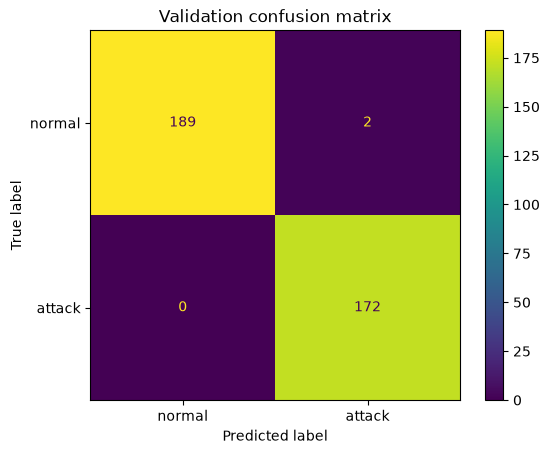

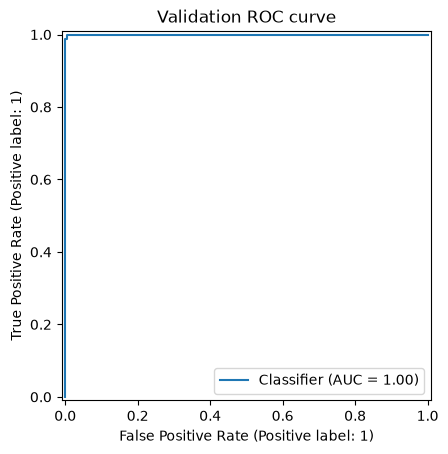

In [12]:
def evaluate_binary_model(model, X, y, dataset_name="Dataset"):
    predictions = model.predict(X)
    probabilities = model.predict_proba(X)[:, 1]

    metrics = {
        "accuracy": accuracy_score(y, predictions),
        "precision": precision_score(y, predictions, zero_division=0),
        "recall": recall_score(y, predictions, zero_division=0),
        "f1": f1_score(y, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y, probabilities),
    }

    print(f"{dataset_name} metrics")
    display(pd.Series(metrics).to_frame("score"))
    print(classification_report(
        y,
        predictions,
        target_names=["normal", "attack"],
        zero_division=0,
    ))

    ConfusionMatrixDisplay.from_predictions(
        y,
        predictions,
        display_labels=["normal", "attack"],
        values_format="d",
    )
    plt.title(f"{dataset_name} confusion matrix")
    plt.show()

    RocCurveDisplay.from_predictions(y, probabilities)
    plt.title(f"{dataset_name} ROC curve")
    plt.show()

    return metrics


validation_metrics = evaluate_binary_model(
    best_pipeline,
    X_validation,
    y_validation,
    dataset_name="Validation",
)

## 12. Final evaluation on the test set

Held-out test metrics


,score
accuracy,0.9890
precision,0.9907
recall,0.9861
f1,0.9884
roc_auc,0.9997


              precision    recall  f1-score   support

      normal       0.99      0.99      0.99       238
      attack       0.99      0.99      0.99       216

    accuracy                           0.99       454
   macro avg       0.99      0.99      0.99       454
weighted avg       0.99      0.99      0.99       454



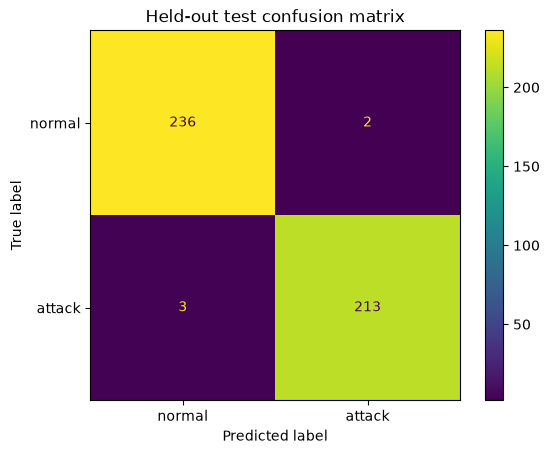

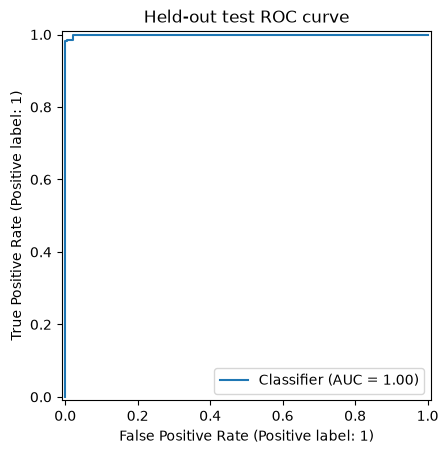

In [13]:
test_metrics = evaluate_binary_model(
    best_pipeline,
    X_test,
    y_test,
    dataset_name="Official KDDTest+" if using_official_test else "Held-out test",
)

## 13. Feature names and XGBoost feature importance

,feature,importance
0,categorical__flag_SF,0.1679
1,numeric__dst_bytes,0.1537
2,numeric__src_bytes,0.1266
3,categorical__service_ecr_i,0.0434
4,numeric__same_srv_rate,0.0294
5,numeric__wrong_fragment,0.0287
6,categorical__protocol_type_icmp,0.0266
7,categorical__service_http,0.0258
8,categorical__service_urp_i,0.0234
9,numeric__count,0.0228


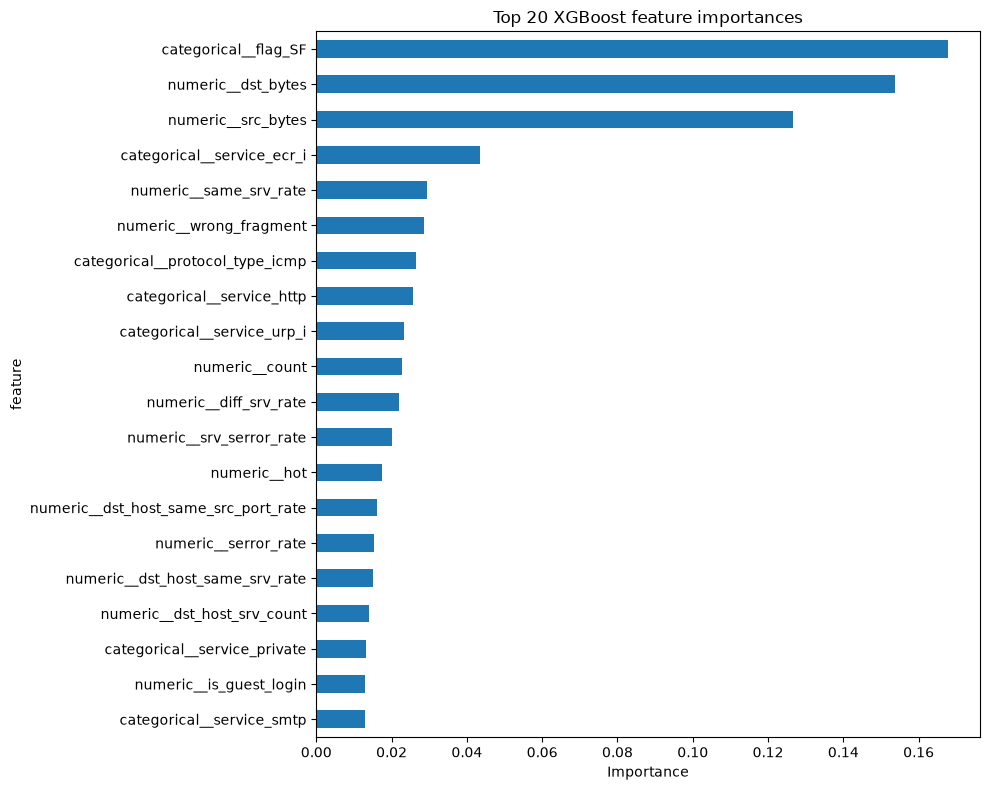

In [14]:
fitted_preprocessor = best_pipeline.named_steps["preprocessor"]
fitted_classifier = best_pipeline.named_steps["classifier"]

feature_names = fitted_preprocessor.get_feature_names_out()

importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": fitted_classifier.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(importance_df.head(20))

importance_df.head(20).sort_values("importance").plot(
    kind="barh",
    x="feature",
    y="importance",
    figsize=(10, 8),
    legend=False,
)
plt.title("Top 20 XGBoost feature importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 14. Save the complete model as a `.pkl` file

In [15]:
# This saves BOTH:
# 1. the fitted preprocessing steps
# 2. the fitted XGBoost classifier
#
# Therefore, new raw NSL-KDD rows can be passed directly to model.predict().

MODEL_PATH = "nsl_kdd_xgboost_pipeline.pkl"
METADATA_PATH = "nsl_kdd_xgboost_metadata.json"

joblib.dump(best_pipeline, MODEL_PATH, compress=3)

import sys
from importlib.metadata import version

metadata = {
    "model_type": "XGBClassifier inside a scikit-learn Pipeline",
    "python_version": sys.version.split()[0],
    "package_versions": {
        "numpy": version("numpy"),
        "pandas": version("pandas"),
        "scipy": version("scipy"),
        "scikit-learn": version("scikit-learn"),
        "xgboost": version("xgboost"),
        "matplotlib": version("matplotlib"),
        "joblib": version("joblib"),
    },
    "target_mapping": {"normal": 0, "attack": 1},
    "categorical_features": CATEGORICAL_FEATURES,
    "numeric_features": NUMERIC_FEATURES,
    "official_test_used": bool(using_official_test),
    "best_cv_f1": float(search.best_score_),
    "best_parameters": search.best_params_,
    "validation_metrics": {key: float(value) for key, value in validation_metrics.items()},
    "test_metrics": {key: float(value) for key, value in test_metrics.items()},
}

with open(METADATA_PATH, "w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=2)

print(f"Model saved successfully: {MODEL_PATH}")
print(f"Metadata saved successfully: {METADATA_PATH}")

Model saved successfully: nsl_kdd_xgboost_pipeline.pkl
Metadata saved successfully: nsl_kdd_xgboost_metadata.json


## 15. Export the exact environment

In [16]:
REQUIREMENTS_PATH = "requirements_nsl_kdd.txt"

requirements = [
    "numpy==2.5.1",
    "pandas==3.0.3",
    "scipy==1.18.0",
    "scikit-learn==1.9.0",
    "xgboost==3.3.0",
    "matplotlib==3.11.1",
    "joblib==1.5.3",
]

with open(REQUIREMENTS_PATH, "w", encoding="utf-8") as file:
    file.write("\n".join(requirements) + "\n")

print(f"Environment file saved: {REQUIREMENTS_PATH}")

Environment file saved: requirements_nsl_kdd.txt


## 16. Verify that the saved model works

In [17]:
loaded_pipeline = joblib.load(MODEL_PATH)

sample_rows = X_test.head(5)
sample_predictions = loaded_pipeline.predict(sample_rows)
sample_probabilities = loaded_pipeline.predict_proba(sample_rows)[:, 1]

verification = pd.DataFrame({
    "predicted_class": np.where(sample_predictions == 1, "attack", "normal"),
    "attack_probability": sample_probabilities,
})

display(verification)

,predicted_class,attack_probability
0,normal,0.0212
1,normal,0.1263
2,normal,0.0966
3,attack,0.9882
4,normal,0.0920


## 17. Download the files from Google Colab

In [18]:
from google.colab import files

files.download(MODEL_PATH)
files.download(METADATA_PATH)
files.download(REQUIREMENTS_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## How to load the model later

```python
import joblib
import pandas as pd

model = joblib.load("nsl_kdd_xgboost_pipeline.pkl")

# `new_data` must contain the same 41 raw feature columns used during training,
# excluding `label` and `difficulty`.
predictions = model.predict(new_data)
attack_probabilities = model.predict_proba(new_data)[:, 1]
```

Because the `.pkl` contains the entire pipeline, you do **not** need a separate `preprocessor.pkl`.
